In [215]:
import pandas as pd
import numpy as np

In [123]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1966 entries, 0 to 1965
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       1954 non-null   float64
 1   RIAGENDR   1948 non-null   float64
 2   PAQ605     1953 non-null   float64
 3   BMXBMI     1948 non-null   float64
 4   LBXGLU     1953 non-null   float64
 5   DIQ010     1948 non-null   float64
 6   LBXGLT     1955 non-null   float64
 7   LBXIN      1957 non-null   float64
 8   age_group  1952 non-null   object 
dtypes: float64(8), object(1)
memory usage: 138.4+ KB


In [4]:
train.describe()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
count,1954.000000,1948.000000,1953.000000,1948.000000,1953.000000,1948.000000,1955.000000,1957.000000
mean,78683.621801,1.510267,1.825397,27.965400,99.491039,2.015914,115.150384,11.862892
std,2924.115709,0.500023,0.399449,7.327616,16.774665,0.187579,46.271615,9.756713
min,73564.000000,1.000000,1.000000,14.500000,63.000000,1.000000,40.000000,0.140000
25%,76194.000000,1.000000,2.000000,22.800000,91.000000,2.000000,87.000000,5.800000
50%,78717.000000,2.000000,2.000000,26.800000,97.000000,2.000000,105.000000,9.030000
75%,81217.000000,2.000000,2.000000,31.300000,104.000000,2.000000,131.000000,14.480000
max,83727.000000,2.000000,7.000000,70.100000,405.000000,3.000000,604.000000,102.290000


In [6]:
train.nunique()

SEQN         1954
RIAGENDR        2
PAQ605          3
BMXBMI        332
LBXGLU         95
DIQ010          3
LBXGLT        224
LBXIN        1292
age_group       2
dtype: int64

In [12]:
train.isnull().sum()

SEQN         12
RIAGENDR     18
PAQ605       13
BMXBMI       18
LBXGLU       13
DIQ010       18
LBXGLT       11
LBXIN         9
age_group    14
dtype: int64

### Handling Missing Values

In [124]:
from sklearn.impute import SimpleImputer

si = SimpleImputer()
si_frequent = SimpleImputer(strategy='most_frequent')

train_gender = si_frequent.fit_transform(train[['RIAGENDR']])
train_paq = si_frequent.fit_transform(train[['PAQ605']])
train_diq = si_frequent.fit_transform(train[['DIQ010']])
train_age = si_frequent.fit_transform(train[['age_group']])
train_bmi = si.fit_transform(train[['BMXBMI']])
train_glu = si.fit_transform(train[['LBXGLU']])
train_glt = si.fit_transform(train[['LBXGLT']])
train_xin = si.fit_transform(train[['LBXIN']])

In [125]:
train_rem = train[['SEQN']]
new_train = np.concatenate((train_rem,train_gender,train_paq,train_bmi,train_glu,train_diq,train_glt,train_xin,train_age),axis=1)

In [206]:
df = pd.DataFrame(new_train,columns = train.columns)
df.isnull().sum()

SEQN         12
RIAGENDR      0
PAQ605        0
BMXBMI        0
LBXGLU        0
DIQ010        0
LBXGLT        0
LBXIN         0
age_group     0
dtype: int64

In [7]:
df.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,2.0,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


### Exploratory Data Analysis

<Axes: ylabel='count'>

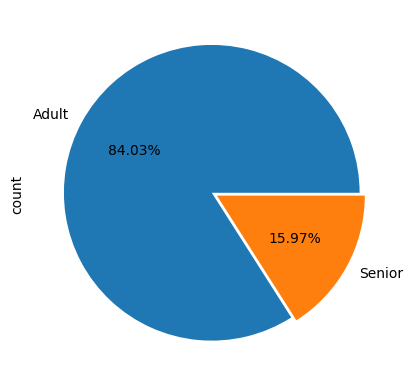

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

df['age_group'].value_counts().plot(kind='pie',explode=[0.02,0.02],autopct='%.2f%%')

<Axes: xlabel='count', ylabel='age_group'>

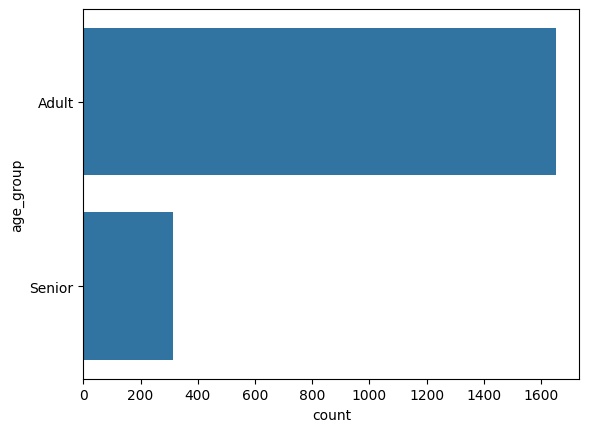

In [57]:
sns.countplot(df['age_group'])

<Axes: xlabel='RIAGENDR', ylabel='age_group'>

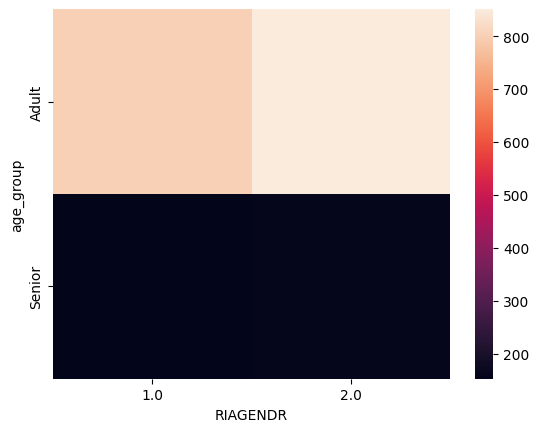

In [53]:
sns.heatmap(pd.crosstab(df['age_group'],df['RIAGENDR']))

From the above heatmap it is clear that there are more Adult females than adult males and there are nearly equal senior males and females

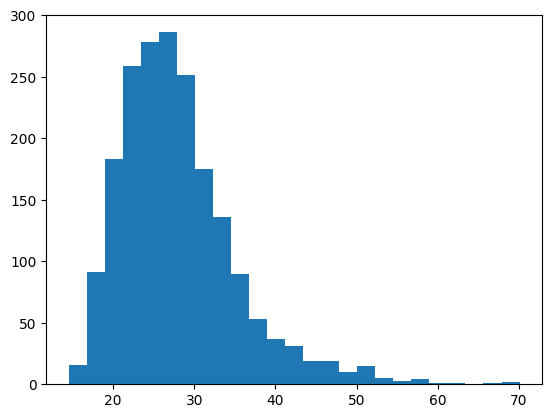

In [9]:
plt.hist(df['BMXBMI'],bins=25)
plt.show()

<Axes: ylabel='count'>

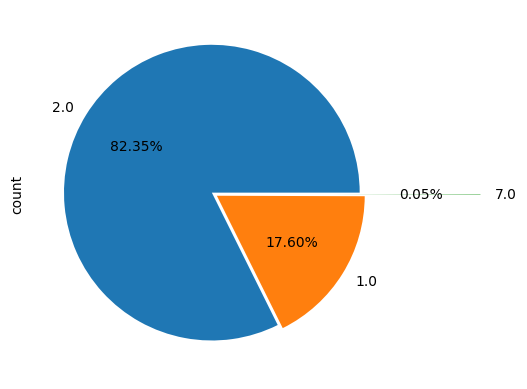

In [65]:
df['PAQ605'].value_counts().plot(kind='pie',explode=[0.02,0.02,0.8],autopct='%.2f%%')

<Axes: xlabel='age_group', ylabel='PAQ605'>

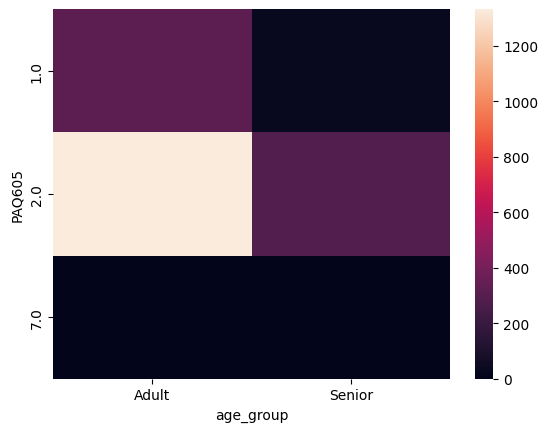

In [68]:
sns.heatmap(pd.crosstab(df['PAQ605'],df['age_group']))

Adults who have good physical activity are near 400-500 in range , Adults those who do not have good physical activity are above 1200 in number whereas very less people chose not to respond.
Seniors those who have good physical activity are near to zero . Seniors those who have very less physical activity are near the range of 500 and very few seniors chose not to answer.

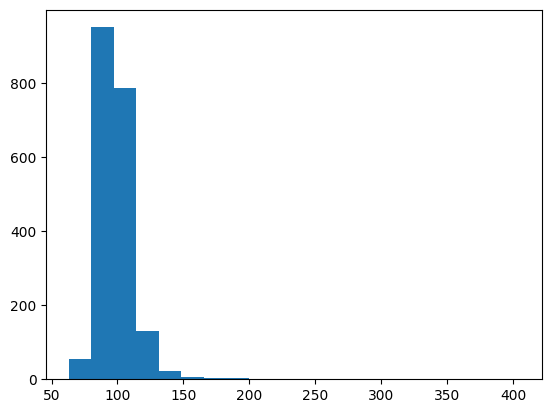

In [78]:
plt.hist(df['LBXGLU'],bins=20)
plt.xlabel = "Increased Insulin Resistance"
plt.ylabel = "Number of people"
plt.show()

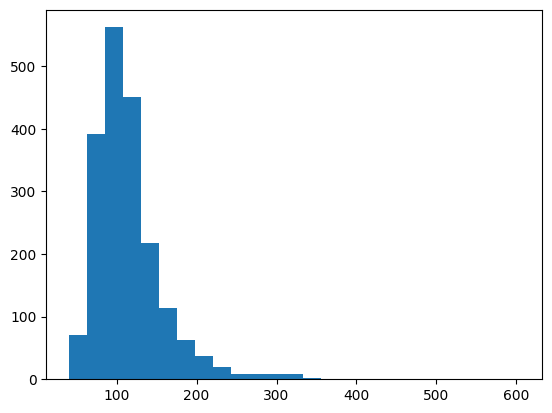

In [80]:
plt.hist(df['LBXGLT'],bins=25)
plt.xlabel = "Reduced Gluecose Tolerance"
plt.ylabel = "Number of people"
plt.show()

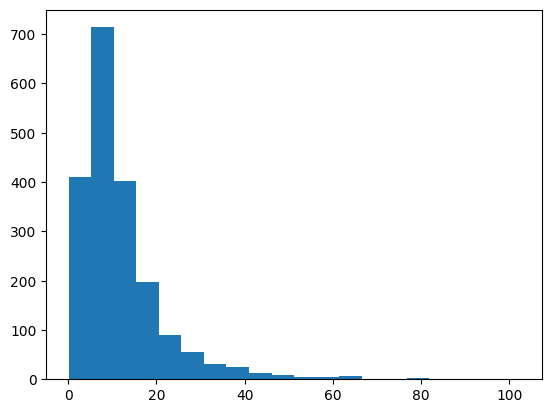

In [81]:
plt.hist(df['LBXIN'],bins=20)
plt.xlabel = "Insulin Level"
plt.ylabel = "Number of people"
plt.show()

<Axes: xlabel='DIQ010'>

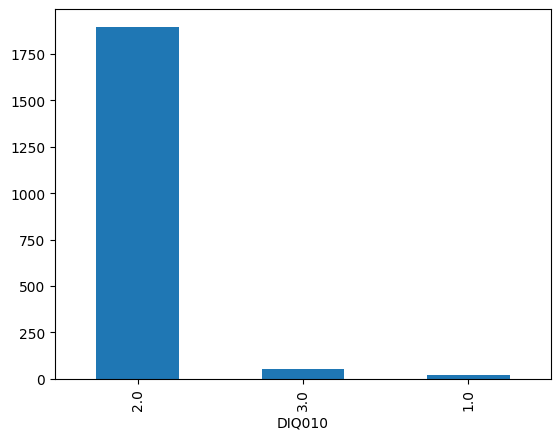

In [84]:
df['DIQ010'].value_counts().plot(kind='bar')

<Axes: xlabel='age_group', ylabel='DIQ010'>

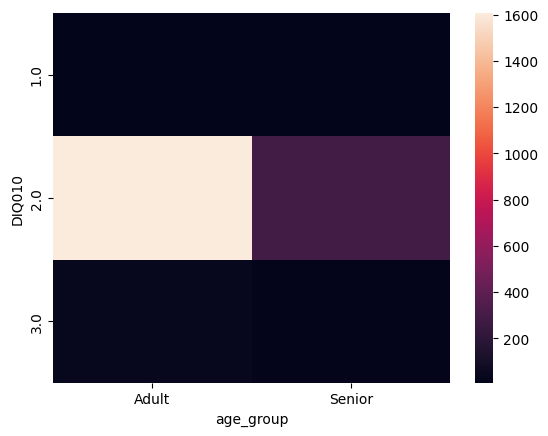

In [85]:
sns.heatmap(pd.crosstab(df['DIQ010'],df['age_group']))

Maximum people on this data have never been told by a Health Professional that they have Diabetes.

### Feature Enineering

In [207]:
condition_weight = [
    (df['BMXBMI'] >= 30),
     ((df['BMXBMI'] >= 25) & (df['BMXBMI'] < 5)),
     ((df['BMXBMI'] < 25) & (df['BMXBMI'] >= 20)),
     (df['BMXBMI'] < 20)
 ]
choices = [3,2,1,0] # 3 represents over Obese , 2 represents overweight , 0 represents underweight and 1 represents fit
df['Weight_Condition'] = np.select(condition_weight,choices)
# Keeping the original columns as well for better predictabilty
df.sample(5)

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group,Weight_Condition
867,78073.0,1.0,2.0,19.8,100.0,2.0,93.0,6.56,Adult,0
1878,83252.0,2.0,2.0,28.8,88.0,2.0,96.0,8.43,Adult,0
1214,80007.0,1.0,2.0,27.5,103.0,2.0,117.0,10.4,Senior,0
1495,81317.0,2.0,2.0,22.3,88.0,2.0,71.0,2.91,Adult,1
968,78645.0,1.0,1.0,30.8,90.0,2.0,112.0,13.26,Adult,3


In [208]:
condition_diabetes = [
     (df['LBXGLU'] >= 126) | (df['LBXGLT'] >= 200),

    ((df['LBXGLU'] >= 100) & (df['LBXGLU'] < 126)) |
    ((df['LBXGLT'] >= 140) & (df['LBXGLT'] < 200))
]
choice = [2,1] # 2 represents Diabetic , 1 represents pre-diabetic and 0 represents non-diabetic
df['Diabetes_condition'] = np.select(condition_diabetes,choice,default=0)
df.sample(5)

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group,Weight_Condition,Diabetes_condition
695,77197.0,2.0,2.0,34.0,90.0,2.0,93.0,7.42,Adult,3,0
1407,80881.0,2.0,2.0,37.3,110.0,2.0,168.0,22.31,Adult,3,1
1426,80979.0,1.0,2.0,30.2,99.0,2.0,94.0,4.26,Adult,3,0
1842,83033.0,2.0,2.0,24.2,91.0,2.0,137.0,8.89,Adult,1,0
289,75118.0,2.0,2.0,34.3,103.0,2.0,84.0,6.33,Adult,3,1


In [209]:
condition_insulin = [
    (df['LBXIN'] < 5),
    (df['LBXIN'] >= 5) & (df['LBXIN'] <= 20),
    (df['LBXIN'] > 20)
]

choices = [0,1,2] # 0 - low , 1 - normal , 2 - high

df['Insulin_Category'] = np.select(condition_insulin, choices)
df.sample(5)

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group,Weight_Condition,Diabetes_condition,Insulin_Category
550,76447.0,2.0,2.0,21.8,86.0,2.0,130.0,4.97,Senior,1,0,0
897,78207.0,2.0,2.0,22.4,96.0,2.0,110.0,12.1,Adult,1,0,1
1826,82978.0,2.0,2.0,21.7,97.0,2.0,105.0,6.75,Adult,1,0,1
1882,83282.0,2.0,2.0,27.8,110.0,2.0,98.0,21.42,Senior,0,1,2
635,76885.0,1.0,2.0,31.3,93.0,2.0,170.0,7.34,Adult,3,1,1


In [211]:
condition = [
    (df['PAQ605']==1),
    (df['PAQ605']==2),
    (df['PAQ605'].isin([7,9]))
]

choices = [2,1,0] # 2 - active , 1 - inactive , 7-9 missing/unknown

df['Activity_Level'] = np.select(condition,choices)
df.sample(5)

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group,Weight_Condition,Diabetes_condition,Insulin_Category,Activity_Level
741,77438.0,2.0,1.0,26.1,95.0,2.0,86.0,10.13,Adult,0,0,1,2
1232,80100.0,1.0,2.0,43.4,91.0,2.0,171.0,40.3,Adult,3,1,2,1
376,75583.0,1.0,2.0,31.9,98.0,2.0,107.0,25.39,Adult,3,0,2,1
1044,79027.0,2.0,2.0,45.9,100.0,2.0,103.0,21.83,Adult,3,1,2,1
570,76557.0,1.0,2.0,27.8,100.0,2.0,98.0,13.04,Adult,0,1,1,1


### Exploratory Data Analysis again

<Axes: xlabel='age_group', ylabel='Weight_Condition'>

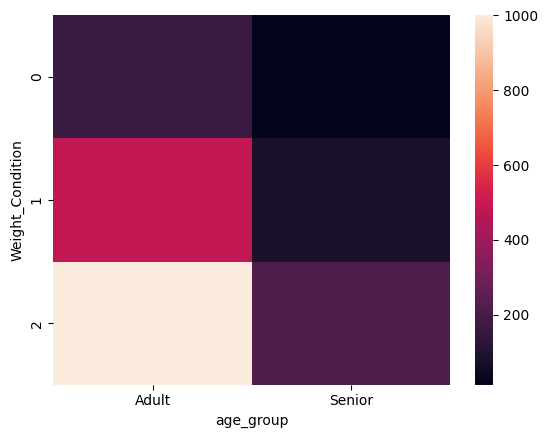

In [22]:
sns.heatmap(pd.crosstab(df['Weight_Condition'],df['age_group']))

Senior overweights are about 300 in number whereas Adult overweights are more than 1000.
Adult fit citizens are around 500 and Senior fit citizens are less than 150.
Both Underweight Senior and Adult citizens are near 200

<Axes: xlabel='age_group', ylabel='Diabetes_condition'>

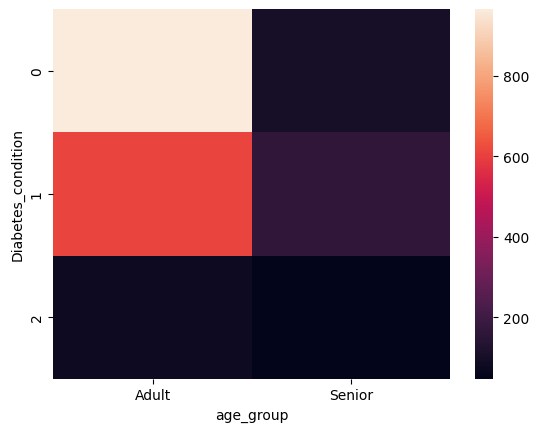

In [23]:
sns.heatmap(pd.crosstab(df['Diabetes_condition'],df['age_group']))

There are very less Diabetic Adults and Seniors.
Adult prediabetic patients are nearly 650-750 in number whereas Senior prediabetic patients are near to 300.
1000+ non-diabetic Adults and near to 100 non diabetic Seniors

<Axes: xlabel='age_group', ylabel='Insulin_Category'>

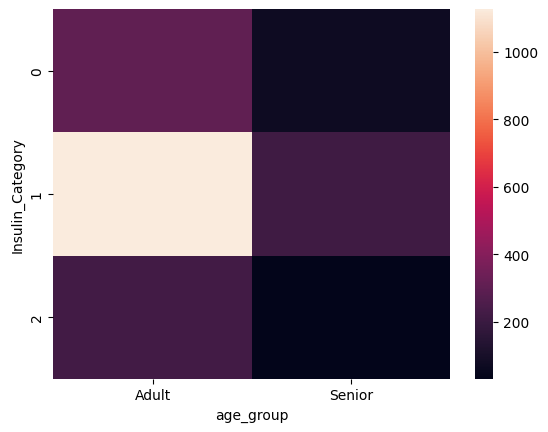

In [212]:
sns.heatmap(pd.crosstab(df['Insulin_Category'],df['age_group']))

Nearly 500 Adults and 100 Seniors have low Insulin Level
1000+ Adults and 250-350 Seniors have Normal Insulin Levels
Nearly 400 Adults and near to zero Seniors have High Insulin level

<Axes: xlabel='age_group', ylabel='Activity_Level'>

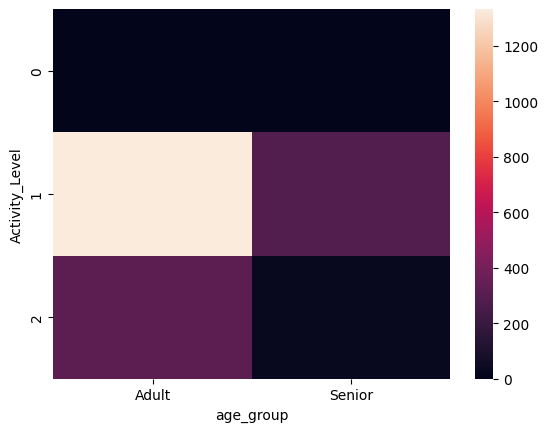

In [213]:
sns.heatmap(pd.crosstab(df['Activity_Level'],df['age_group']))

500 Adults and near to 0 Seniors have a good activity Level
1000+ Adults and 55-600 seniors have 0 activity level

### Model Training

In [214]:
from sklearn.model_selection import train_test_split
df.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group,Weight_Condition,Diabetes_condition,Insulin_Category,Activity_Level
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult,3,1,1,1
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult,1,0,0,1
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult,1,0,1,1
3,73577.0,1.0,2.0,28.9,104.0,2.0,84.0,16.15,Adult,0,1,1,1
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult,3,1,1,2


In [216]:
df.drop(columns='SEQN',inplace=True)
X_train , X_test , y_train , y_test = train_test_split(df.drop(columns='age_group'),df['age_group'],test_size=0.2,random_state=42)
print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)

(1572, 11) (394, 11)
(1572,) (394,)


In [217]:
X_train.head()

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,Weight_Condition,Diabetes_condition,Insulin_Category,Activity_Level
759,2.0,2.0,24.6,89.0,2.0,134.0,3.64,1,0,0,1
746,1.0,2.0,30.5,102.0,2.0,90.0,12.8,3,1,1,1
1412,1.0,2.0,23.9,94.0,2.0,114.0,7.63,1,0,1,1
861,2.0,2.0,41.9,99.0,2.0,110.0,21.94,3,0,2,1
843,1.0,1.0,30.3,93.0,2.0,114.0,9.52,3,0,1,2


In [218]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['age_group'])
le.classes_

array(['Adult', 'Senior'], dtype=object)

In [219]:
y_train = le.transform(y_train)
y_test = le.transform(y_test)

In [220]:
X_train = X_train.astype(float) # To remove object type variables
X_test = X_test.astype(float)

In [224]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

si = SimpleImputer()
si_frequent = SimpleImputer(strategy='most_frequent')

trf = ColumnTransformer([
    ('test_gender',SimpleImputer(strategy='most_frequent'),[1]),
    ('test_paq',SimpleImputer(strategy='most_frequent'),[2]),    
    ('test_bmi',SimpleImputer(),[3]),
    ('test_glu',SimpleImputer(),[4]),
    ('test_diq',SimpleImputer(strategy='most_frequent'),[5]),
    ('test_glt',SimpleImputer(),[6]),
    ('test_xin',SimpleImputer(),[7])
],remainder='passthrough')
trf.set_output(transform="pandas")
X = trf.fit_transform(test)
X.rename(columns={'test_gender__RIAGENDR':'RIAGENDR',
                 'test_paq__PAQ605':'PAQ605',
                 'test_diq__DIQ010':'DIQ010',
                 'test_bmi__BMXBMI':'BMXBMI',
                 'test_glu__LBXGLU':'LBXGLU',
                 'test_glt__LBXGLT':'LBXGLT',
                 'test_xin__LBXIN':'LBXIN',
                 'remainder__SEQN':'SEQN'},inplace=True)
X.head()

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,SEQN
0,1.0,1.0,32.2,96.0,2.0,135.0,15.11,77017.0
1,2.0,2.0,26.3,100.0,2.0,141.0,15.26,75580.0
2,1.0,2.0,28.6,107.0,2.0,136.0,8.82,73820.0
3,2.0,1.0,22.1,93.0,2.0,111.0,12.13,80489.0
4,1.0,1.0,24.7,91.0,2.0,105.0,3.12,82047.0


In [225]:
X.drop(columns='SEQN',inplace=True)
X.head()

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
0,1.0,1.0,32.2,96.0,2.0,135.0,15.11
1,2.0,2.0,26.3,100.0,2.0,141.0,15.26
2,1.0,2.0,28.6,107.0,2.0,136.0,8.82
3,2.0,1.0,22.1,93.0,2.0,111.0,12.13
4,1.0,1.0,24.7,91.0,2.0,105.0,3.12


In [226]:
condition_weight = [
     (X['BMXBMI'] >= 25),
     ((X['BMXBMI'] < 25) & (X['BMXBMI'] >= 20)),
     (X['BMXBMI'] < 20)
 ]
choices = [2,1,0] # 2 represents overweight , 0 represents underweight and 1 represents fit
X['Weight_Condition'] = np.select(condition_weight,choices)
X.sample(5)

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,Weight_Condition
211,2.0,2.0,22.2,98.0,2.0,96.0,8.51,1
126,1.0,1.0,31.8,100.0,2.0,102.0,10.61,2
269,2.0,2.0,31.6,115.0,2.0,280.0,11.07,2
283,2.0,1.0,30.4,108.0,2.0,132.0,12.03,2
106,2.0,2.0,26.4,95.0,2.0,80.0,11.69,2


In [227]:
condition_diabetes = [
     (X['LBXGLU'] >= 126) | (X['LBXGLT'] >= 200),

    ((X['LBXGLU'] >= 100) & (X['LBXGLU'] < 126)) |
    ((X['LBXGLT'] >= 140) & (X['LBXGLT'] < 200))
]
choice = [2,1] # 2 represents Diabetic , 1 represents pre-diabetic and 0 represents non-diabetic
X['Diabetes_condition'] = np.select(condition_diabetes,choice,default=0)
X.sample(5)

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,Weight_Condition,Diabetes_condition
235,1.0,1.0,28.5,98.0,2.0,93.0,31.26,2,0
122,1.0,2.0,24.8,97.0,2.0,118.0,2.85,1,0
262,1.0,2.0,25.8,100.0,2.0,100.0,8.90,2,1
195,2.0,2.0,24.8,104.0,2.0,89.0,7.21,1,1
203,2.0,2.0,28.2,90.0,2.0,99.0,19.21,2,0


In [228]:
condition_insulin = [
    (X['LBXIN'] < 5),
    (X['LBXIN'] >= 5) & (X['LBXIN'] <= 20),
    (X['LBXIN'] > 20)
]

choices = [0,1,2] # 0 - low , 1 - normal , 2 - high

X['Insulin_Category'] = np.select(condition_insulin, choices)
X.sample(5)

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,Weight_Condition,Diabetes_condition,Insulin_Category
26,2.0,2.0,24.2,89.0,2.0,78.0,36.50,1,0,2
76,2.0,2.0,26.8,98.0,2.0,114.0,9.85,2,0,1
251,1.0,2.0,22.4,108.0,2.0,80.0,7.54,1,1,1
306,1.0,2.0,29.0,118.0,2.0,140.0,9.46,2,1,1
74,2.0,2.0,50.4,91.0,2.0,126.0,26.79,2,0,2


In [229]:
condition = [
    (X['PAQ605']==1),
    (X['PAQ605']==2),
    (X['PAQ605'].isin([7,9]))
]

choices = [2,1,0] # 2 - active , 1 - inactive , 7-9 missing/unknown

X['Activity_Level'] = np.select(condition,choices)
X.sample(5)

,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,Weight_Condition,Diabetes_condition,Insulin_Category,Activity_Level
208,2.0,2.0,19.9,79.0,2.0,62.0,10.61,0,0,1,1
24,2.0,2.0,32.6,97.0,2.0,95.0,18.98,2,0,1,1
35,1.0,1.0,25.1,99.0,2.0,86.0,6.34,2,0,1,2
148,2.0,2.0,24.2,90.0,2.0,76.0,4.85,1,0,0,1
199,2.0,2.0,22.3,103.0,2.0,123.0,4.21,1,1,0,1


### Model Training

In [268]:
# Basic ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
     n_estimators=600,
    max_depth=8,
    min_samples_leaf=3,
    min_samples_split=6,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.5,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight= (338/56),  # important for imbalance
        eval_metric="logloss",
        random_state=42
    )
}

In [270]:
from sklearn.metrics import f1_score, classification_report

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\n{name}")
    print("F1 Score:", f1)


Logistic Regression
F1 Score: 0.3978494623655914

Random Forest
F1 Score: 0.3698630136986301

AdaBoost
F1 Score: 0.12903225806451613

Gradient Boosting
F1 Score: 0.1095890410958904

XGBoost
F1 Score: 0.22807017543859648


In [272]:
rf = RandomForestClassifier(
     n_estimators=600,
    max_depth=8,
    min_samples_leaf=3,
    min_samples_split=6,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42
    )
lr = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    )

In [273]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print(np.mean(cross_val_score(rf,X_test,y_test,scoring='accuracy',cv=10)))

0.8251923076923078


In [274]:
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print(np.mean(cross_val_score(lr,X_test,y_test,scoring='accuracy',cv=10)))

0.6905128205128206


Therefore we will use RandomForestClassifier here.

In [275]:
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
y_pred

array([1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [276]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[275  63]
 [ 29  27]]
              precision    recall  f1-score   support

           0       0.90      0.81      0.86       338
           1       0.30      0.48      0.37        56

    accuracy                           0.77       394
   macro avg       0.60      0.65      0.61       394
weighted avg       0.82      0.77      0.79       394



In [277]:
import numpy as np
from sklearn.metrics import f1_score

best_t, best_f1 = 0, 0

for t in np.arange(0.20, 0.50, 0.005):
    y_pred = (proba > t).astype(int)
    f1 = f1_score(y_test, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t, best_f1)

0.37000000000000016 0.3783783783783784


In [279]:
proba = rf.predict_proba(X_test)[:, 1]

y_pred_035 = (proba > 0.37).astype(int)
y_predicted = rf.predict(X)
y_predicted

array([0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [280]:
y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[275  63]
 [ 29  27]]
              precision    recall  f1-score   support

           0       0.90      0.81      0.86       338
           1       0.30      0.48      0.37        56

    accuracy                           0.77       394
   macro avg       0.60      0.65      0.61       394
weighted avg       0.82      0.77      0.79       394



In [299]:
y_submission = rf.predict(X)
y_submission

array([0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [300]:
df_results = pd.DataFrame({
    "age_group": y_submission
})

df_results.to_csv("sample-submission.csv", index=False)

In [301]:
print(X.shape,y_submission.shape)

(312, 11) (312,)
